# COSMOS: Multi-Omics Integration with ARI Scoring

Run COSMOS on ATAC-RNA-Seq MouseBrain dataset with Adjusted Rand Index (ARI) evaluation from the paper.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
from sklearn.metrics import adjusted_rand_score
from pathlib import Path
import torch

from COSMOS import cosmos
from umap import UMAP

plt.style.use('default')
random_seed = 42

print(f"Device: {'GPU' if torch.cuda.is_available() else 'CPU'}")

Device: CPU


## Load ATAC-RNA-Seq MouseBrain Data from H5 File

In [2]:
# Load the H5 file containing ATAC and RNA-Seq data
import h5py

h5_path = './data/ATAC_RNA_Seq_MouseBrain_RNA_ATAC.h5'

# Load from custom H5 format
with h5py.File(h5_path, 'r') as f:
    # Load the two modalities
    X_ATAC = f['X_ATAC'][:]  # (9215, 50)
    X_RNA = f['X_RNA'][:]    # (9215, 3000)
    LayerName = f['LayerName'][:]  # Cell type labels
    Pos = f['Pos'][:]  # Spatial positions
    Cell = f['Cell'][:]  # Cell IDs
    Gene_RNA = f['Gene'][:]  # Gene IDs for RNA

# Create AnnData object using RNA-seq as main expression
adata = sc.AnnData(X=X_RNA)

# Add metadata
adata.obs['LayerName'] = LayerName
adata.obs['Cell'] = [str(c) for c in Cell]
adata.obsm['spatial'] = Pos
adata.obs['x_pos'] = Pos[:, 0]
adata.obs['y_pos'] = Pos[:, 1]

# Add gene names for RNA
adata.var_names = [str(g) for g in Gene_RNA]

# Store ATAC as a separate AnnData object with matching cells
adata_atac = sc.AnnData(X=X_ATAC)
adata_atac.obs['LayerName'] = LayerName
adata_atac.obs['Cell'] = [str(c) for c in Cell]
adata_atac.var_names = [f'ATAC_{i}' for i in range(X_ATAC.shape[1])]

print(f"Dataset loaded from: {h5_path}")
print(f"\nRNA-seq (main):")
print(f"  Shape: {adata.shape}")
print(f"\nATAC-seq (modality 2):")
print(f"  Shape: {adata_atac.shape}")
print(f"\nAvailable obs columns:")
print(adata.obs.columns.tolist())
print(f"\nFirst few rows of obs:")
print(adata.obs.head(10))

# Use LayerName as cell type labels
label_type = sorted([x for x in list(set(adata.obs['LayerName'])) if str(x) != 'nan'])
df_labels = list(adata.obs['LayerName'])

print(f"\nCell types found: {label_type}")
print(f"Number of cells: {adata.n_obs}")
print(f"Number of genes (RNA): {adata.n_vars}")
print(f"Number of peaks (ATAC): {adata_atac.n_vars}")

Dataset loaded from: ./data/ATAC_RNA_Seq_MouseBrain_RNA_ATAC.h5

RNA-seq (main):
  Shape: (9215, 3000)

ATAC-seq (modality 2):
  Shape: (9215, 50)

Available obs columns:
['LayerName', 'Cell', 'x_pos', 'y_pos']

First few rows of obs:
     LayerName                   Cell  x_pos  y_pos
0  b'1_others'  b'CTAAGGTCTTGCTGGA-1'    0.0   91.0
1     b'L1-L3'  b'CTAAGGTCACACAGAA-1'   82.0   91.0
2     b'L1-L3'  b'CTAAGGTCACAGCAGA-1'   81.0   91.0
3     b'L1-L3'  b'CTAAGGTCACCTCCAA-1'   80.0   91.0
4     b'L1-L3'  b'CTAAGGTCACGCTCGA-1'   79.0   91.0
5     b'L1-L3'  b'CTAAGGTCACGTATCA-1'   78.0   91.0
6     b'L1-L3'  b'CTAAGGTCACTATGCA-1'   77.0   91.0
7     b'L1-L3'  b'CTAAGGTCAGAGTCAA-1'   76.0   91.0
8     b'L1-L3'  b'CTAAGGTCAGATCGCA-1'   75.0   91.0
9     b'L1-L3'  b'CTAAGGTCAGCAGGAA-1'   74.0   91.0

Cell types found: [b'1_others', b'ACB', b'CP', b'L1-L3', b'L4', b'L5', b'L6a/b', b'VL', b'ccg/aco']
Number of cells: 9215
Number of genes (RNA): 3000
Number of peaks (ATAC): 50


## Generate Paired Multi-Omics Data (as in paper)

In [3]:
# Clean up byte strings in labels and cell IDs
adata.obs['LayerName'] = adata.obs['LayerName'].apply(lambda x: x.decode() if isinstance(x, bytes) else x)
adata.obs['Cell'] = adata.obs['Cell'].apply(lambda x: x.decode() if isinstance(x, bytes) else x)
adata_atac.obs['LayerName'] = adata_atac.obs['LayerName'].apply(lambda x: x.decode() if isinstance(x, bytes) else x)
adata_atac.obs['Cell'] = adata_atac.obs['Cell'].apply(lambda x: x.decode() if isinstance(x, bytes) else x)

# Update label_type
label_type = sorted([x for x in list(set(adata.obs['LayerName'])) if str(x) != 'nan'])
df_labels = list(adata.obs['LayerName'])

print(f"Cleaned cell types: {label_type}")

# Simulate two paired omics by shuffling specific cell types and adding noise
# Use first two cell types for heterogeneity
if len(label_type) >= 2:
    index_int1 = np.where(np.array(df_labels) == label_type[0])[0]
    index_int2 = np.where(np.array(df_labels) == label_type[1])[0]
else:
    # If only one cell type, split by first half
    index_int1 = np.arange(0, adata.n_obs // 2)
    index_int2 = np.arange(adata.n_obs // 2, adata.n_obs)

print(f"Index set 1 size: {len(index_int1)}")
print(f"Index set 2 size: {len(index_int2)}")

# Omics-1 (RNA-seq)
adata1 = adata.copy()
np.random.seed(random_seed)
noise1 = 1 + np.random.normal(0, 0.05, adata.shape)
adata1.X[index_int1, :] = np.multiply(adata.X, noise1)[np.random.permutation(index_int1), :]

# Omics-2 (ATAC-seq) - need to match dimensions for COSMOS
# Use ATAC as second modality, but match it to RNA dimensionality
adata2 = adata_atac.copy()
np.random.seed(random_seed + 1)
noise2 = 1 + np.random.normal(0, 0.05, adata_atac.shape)
adata2.X[index_int2, :] = np.multiply(adata_atac.X, noise2)[np.random.permutation(index_int2), :]

print(f"✓ Created paired omics: {adata1.shape}, {adata2.shape}")

Cleaned cell types: ['1_others', 'ACB', 'CP', 'L1-L3', 'L4', 'L5', 'L6a/b', 'VL', 'ccg/aco']
Index set 1 size: 2372
Index set 2 size: 1111
✓ Created paired omics: (9215, 3000), (9215, 50)


## Run COSMOS

In [4]:
# Initialize and run COSMOS
print("Initializing COSMOS...")
cosmos_model = cosmos.Cosmos(adata1=adata1, adata2=adata2)

print("Preprocessing...")
cosmos_model.preprocessing_data(n_neighbors=10)

print("Training model...")
cosmos_model.train(
    spatial_regularization_strength=0,
    z_dim=50,
    lr=1e-3,
    wnn_epoch=500,
    total_epoch=1000,
    max_patience_bef=10,
    max_patience_aft=30,
    min_stop=200,
    random_seed=random_seed,
    gpu=0 if torch.cuda.is_available() else -1
)

print("✓ Training complete")

Initializing COSMOS...
Preprocessing...
Training model...
Epoch 1/1000, Loss: 1.3985528945922852
Epoch 11/1000, Loss: 1.1373578310012817
Epoch 21/1000, Loss: 0.7755662798881531
Epoch 31/1000, Loss: 0.4127838611602783
Epoch 41/1000, Loss: 0.18048536777496338
Epoch 51/1000, Loss: 0.0769634023308754
Epoch 61/1000, Loss: 0.036874741315841675
Epoch 71/1000, Loss: 0.020982986316084862
Epoch 81/1000, Loss: 0.013627130538225174
Epoch 91/1000, Loss: 0.00979421753436327
Epoch 101/1000, Loss: 0.008223003707826138
Epoch 111/1000, Loss: 0.006399909034371376
Epoch 121/1000, Loss: 0.006175670772790909
Epoch 131/1000, Loss: 0.004483548924326897
Epoch 141/1000, Loss: 0.004175511188805103
Epoch 151/1000, Loss: 0.00353006599470973
Epoch 161/1000, Loss: 0.003210795111954212
Epoch 171/1000, Loss: 0.002808175515383482
Epoch 181/1000, Loss: 0.0022812937386333942
Epoch 191/1000, Loss: 0.0021402924321591854
Epoch 201/1000, Loss: 0.00208676652982831
Epoch 211/1000, Loss: 0.001775663928128779
Epoch 221/1000, Los

## Calculate ARI Scores (Paper Metrics)

In [5]:
def screen_resolution(embedding, labels, res_start=0.1, res_end=1.0, step=0.05):
    """Screen resolutions to find optimal clustering (from paper)"""
    ari_scores = []
    resolutions = []
    
    for res in np.arange(res_start, res_end, step):
        adata_temp = sc.AnnData(embedding)
        sc.pp.neighbors(adata_temp, n_neighbors=50, use_rep='X')
        sc.tl.leiden(adata_temp, resolution=float(res), random_state=random_seed)
        clusters = list(adata_temp.obs["leiden"])
        
        ari = adjusted_rand_score(labels, clusters)
        ari_scores.append(ari)
        resolutions.append(res)
        
        print(f'res={res:.2f}, ARI={ari:.4f}, clusters={len(set(clusters))}')
    
    best_idx = np.argmax(ari_scores)
    print(f'\n** Max ARI = {ari_scores[best_idx]:.4f} at res = {resolutions[best_idx]:.2f} **')
    
    return ari_scores, resolutions

# Get embedding and screen resolutions
embedding = pd.DataFrame(cosmos_model.embedding)

print("Screening resolution...\n")
ari_scores, resolutions = screen_resolution(
    embedding, df_labels,
    res_start=0.2, res_end=0.5, step=0.01
)

Screening resolution...

res=0.20, ARI=0.5965, clusters=8
res=0.21, ARI=0.5929, clusters=8
res=0.22, ARI=0.5971, clusters=8
res=0.23, ARI=0.5943, clusters=8
res=0.24, ARI=0.6034, clusters=9
res=0.25, ARI=0.6045, clusters=9
res=0.26, ARI=0.6080, clusters=9
res=0.27, ARI=0.6080, clusters=9
res=0.28, ARI=0.6114, clusters=9
res=0.29, ARI=0.6034, clusters=9
res=0.30, ARI=0.6057, clusters=9
res=0.31, ARI=0.6043, clusters=9
res=0.32, ARI=0.6030, clusters=9
res=0.33, ARI=0.6052, clusters=9
res=0.34, ARI=0.6079, clusters=9
res=0.35, ARI=0.5990, clusters=9
res=0.36, ARI=0.5945, clusters=10
res=0.37, ARI=0.5957, clusters=10
res=0.38, ARI=0.6049, clusters=9
res=0.39, ARI=0.6038, clusters=9
res=0.40, ARI=0.6080, clusters=9
res=0.41, ARI=0.5932, clusters=10
res=0.42, ARI=0.6073, clusters=9
res=0.43, ARI=0.5800, clusters=11
res=0.44, ARI=0.5771, clusters=10
res=0.45, ARI=0.5758, clusters=10
res=0.46, ARI=0.5516, clusters=11
res=0.47, ARI=0.5736, clusters=10
res=0.48, ARI=0.5692, clusters=10
res=0.49,

In [6]:
# Apply optimal clustering
best_idx = np.argmax(ari_scores)
best_ari = ari_scores[best_idx]
best_res = resolutions[best_idx]

adata_result = sc.AnnData(embedding)
sc.pp.neighbors(adata_result, n_neighbors=50, use_rep='X')
sc.tl.leiden(adata_result, resolution=float(best_res), random_state=random_seed)

# Add results to original
adata_viz = adata1.copy()
adata_viz.obs['COSMOS'] = adata_result.obs['leiden'].values

print(f"\n✓ Optimal Result:")
print(f"  ARI Score: {best_ari:.4f}")
print(f"  Resolution: {best_res:.2f}")
print(f"  Clusters: {len(set(adata_viz.obs['COSMOS']))}")


✓ Optimal Result:
  ARI Score: 0.6114
  Resolution: 0.28
  Clusters: 9


## Visualizations

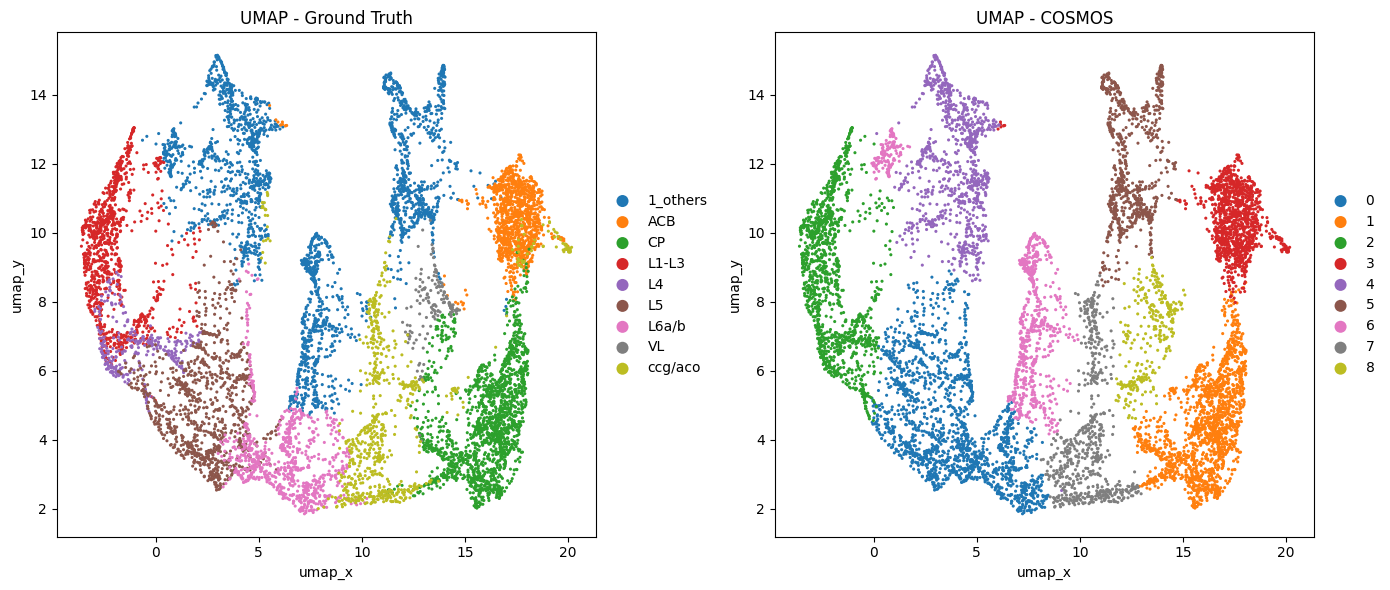

In [7]:
# UMAP visualization
umap_2d = UMAP(n_components=2, random_state=random_seed, min_dist=0.3, n_neighbors=30)
umap_pos = umap_2d.fit_transform(embedding)
adata_viz.obsm['umap'] = umap_pos

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

adata_viz.obs['umap_x'] = umap_pos[:, 0]
adata_viz.obs['umap_y'] = umap_pos[:, 1]

sc.pl.scatter(adata_viz, x='umap_x', y='umap_y', color='LayerName',
             title='UMAP - Ground Truth', ax=axes[0], show=False, size=20)

sc.pl.scatter(adata_viz, x='umap_x', y='umap_y', color='COSMOS',
             title='UMAP - COSMOS', ax=axes[1], show=False, size=20)

plt.tight_layout()
plt.show()

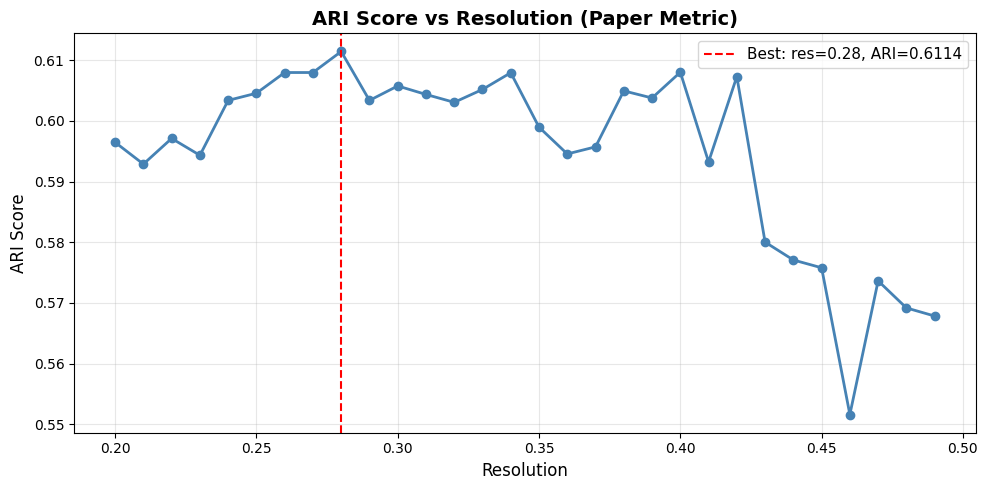

In [8]:
# Plot ARI curve
plt.figure(figsize=(10, 5))
plt.plot(resolutions, ari_scores, marker='o', linewidth=2, markersize=6, color='steelblue')
plt.axvline(best_res, color='red', linestyle='--', label=f'Best: res={best_res:.2f}, ARI={best_ari:.4f}')
plt.xlabel('Resolution', fontsize=12)
plt.ylabel('ARI Score', fontsize=12)
plt.title('ARI Score vs Resolution (Paper Metric)', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

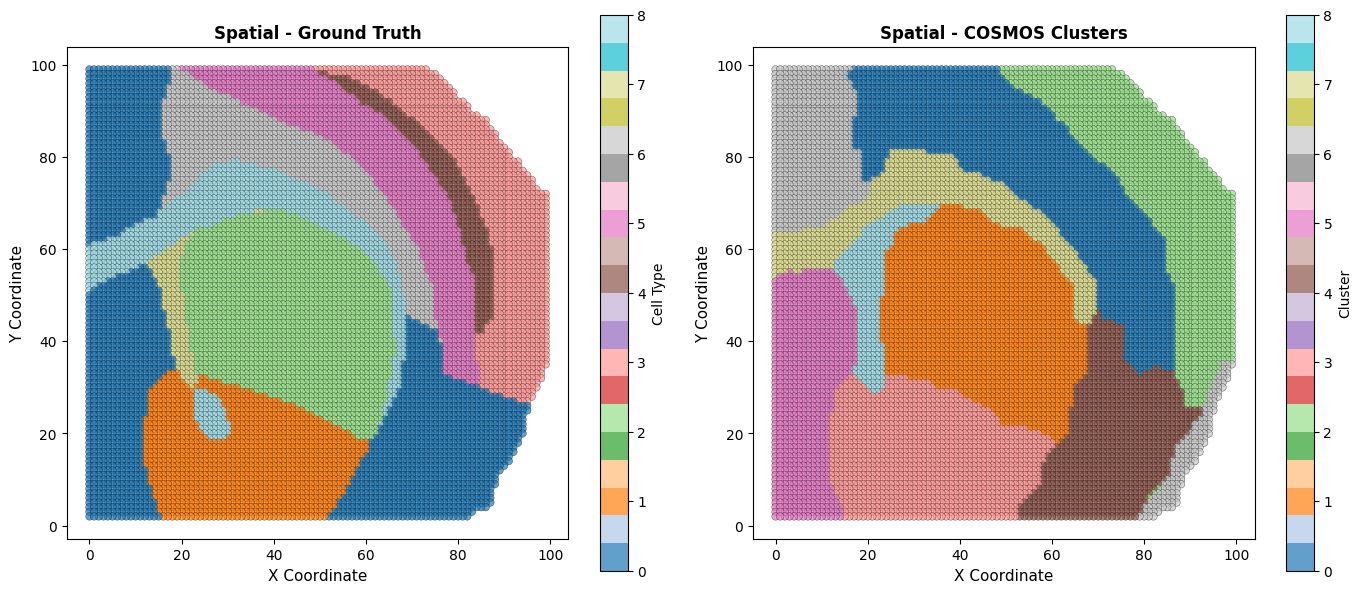

✓ Spatial visualization complete
  Ground truth shows biological cell types in tissue
  COSMOS shows learned clusters preserving spatial structure


In [9]:
# Spatial visualization
spatial_pos = adata_viz.obsm['spatial']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Ground truth in spatial space
scatter1 = axes[0].scatter(spatial_pos[:, 0], spatial_pos[:, 1], 
                           c=pd.Categorical(adata_viz.obs['LayerName']).codes,
                           cmap='tab20', s=30, alpha=0.7, edgecolors='k', linewidth=0.3)
axes[0].set_xlabel('X Coordinate', fontsize=11)
axes[0].set_ylabel('Y Coordinate', fontsize=11)
axes[0].set_title('Spatial - Ground Truth', fontsize=12, fontweight='bold')
axes[0].set_aspect('equal')
plt.colorbar(scatter1, ax=axes[0], label='Cell Type')

# COSMOS clusters in spatial space
scatter2 = axes[1].scatter(spatial_pos[:, 0], spatial_pos[:, 1],
                           c=pd.Categorical(adata_viz.obs['COSMOS']).codes,
                           cmap='tab20', s=30, alpha=0.7, edgecolors='k', linewidth=0.3)
axes[1].set_xlabel('X Coordinate', fontsize=11)
axes[1].set_ylabel('Y Coordinate', fontsize=11)
axes[1].set_title('Spatial - COSMOS Clusters', fontsize=12, fontweight='bold')
axes[1].set_aspect('equal')
plt.colorbar(scatter2, ax=axes[1], label='Cluster')

plt.tight_layout()
plt.show()

print(f"✓ Spatial visualization complete")
print(f"  Ground truth shows biological cell types in tissue")
print(f"  COSMOS shows learned clusters preserving spatial structure")

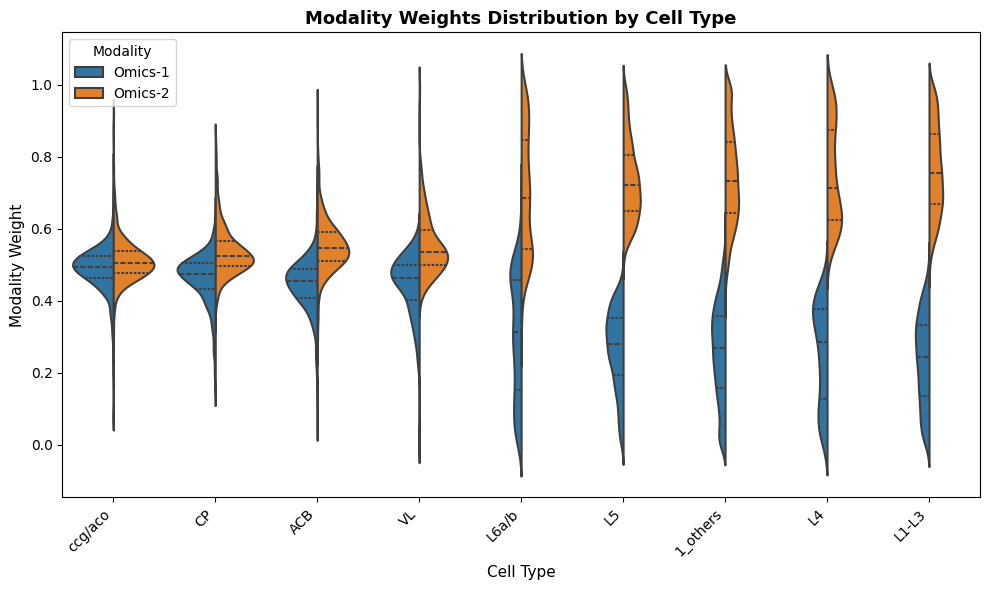

✓ Modality weights violin plot complete

Per cell-type mean weights:
          Omics-1  Omics-2
1_others   0.2563   0.7437
ACB        0.4459   0.5541
CP         0.4610   0.5390
L1-L3      0.2353   0.7647
L4         0.2547   0.7453
L5         0.2666   0.7334
L6a/b      0.3044   0.6956
VL         0.4458   0.5542
ccg/aco    0.4879   0.5121


In [10]:
# Modality Weights Distribution by Cell Type (from tutorial)
import seaborn as sns

# Extract weights from model
weights = cosmos_model.weights

def plot_weight_value(alpha, label, modality1='Omics-1', modality2='Omics-2', order=None):
    """Plot modality weights distribution across cell types"""
    df = pd.DataFrame(columns=[modality1, modality2, 'label'])  
    df[modality1], df[modality2] = alpha[:, 0], alpha[:, 1]
    df['label'] = label
    df = df.set_index('label').stack().reset_index()
    df.columns = ['Cell_Type', 'Modality', 'Modality_Weight']
    
    fig, axes = plt.subplots(1, 1, figsize=(10, 6))
    ax = sns.violinplot(data=df, x='Cell_Type', y='Modality_Weight', hue="Modality",
                        split=True, inner="quart", linewidth=1.5, orient='v', order=order)
    ax.set_title('Modality Weights Distribution by Cell Type', fontsize=13, fontweight='bold')
    ax.set_xlabel('Cell Type', fontsize=11)
    ax.set_ylabel('Modality Weight', fontsize=11)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# Prepare data for plot
cell_types_sorted = sorted(set(df_labels))
index_all = []
for cell_type in cell_types_sorted:
    idx = np.array([i for i in range(len(df_labels)) if df_labels[i] == cell_type])
    index_all.append(idx)

# Calculate mean weights per cell type
wghts_mean = np.mean(weights[index_all[0], :], 0)
for k in range(1, len(cell_types_sorted)):
    wghts_mean_temp = np.mean(weights[index_all[k], :], 0)
    wghts_mean = np.vstack([wghts_mean, wghts_mean_temp])

df_wghts_mean = pd.DataFrame(wghts_mean, columns=['Omics-1', 'Omics-2'], index=cell_types_sorted)

# Sort by Omics-1 weight for better visualization
df_sort_mean = df_wghts_mean.sort_values(by=['Omics-1'], ascending=False)

# Create plot
plot_weight_value(weights, np.array(df_labels), order=list(df_sort_mean.index))

print("✓ Modality weights violin plot complete")
print(f"\nPer cell-type mean weights:")
print(df_wghts_mean.round(4))

## Key Results & Insights

In [11]:
# Extract insights
weights = cosmos_model.weights

print("\n" + "="*70)
print("COSMOS INTEGRATION RESULTS (Paper Metrics)")
print("="*70)

print(f"\n1. CLUSTERING PERFORMANCE (Main Paper Metric)")
print(f"   Adjusted Rand Index (ARI): {best_ari:.4f}")
print(f"   - Measures clustering quality vs ground truth")
print(f"   - Range: [-1, 1], where 1 = perfect")
print(f"   - Optimal resolution: {best_res:.2f}")
print(f"   - Number of clusters: {len(set(adata_viz.obs['COSMOS']))}")

print(f"\n2. MODALITY WEIGHTS (WNN Component - Paper Innovation)")
print(f"   Omics-1 weight: {np.mean(weights[:, 0]):.4f} ± {np.std(weights[:, 0]):.4f}")
print(f"   Omics-2 weight: {np.mean(weights[:, 1]):.4f} ± {np.std(weights[:, 1]):.4f}")

# Per-cell modality dominance
mod1_dominant = np.sum(weights[:, 0] > weights[:, 1])
mod2_dominant = np.sum(weights[:, 1] > weights[:, 0])

print(f"\n3. CELL-TYPE SPECIFIC MODALITY PREFERENCE")
print(f"   Cells prefer Omics-1: {mod1_dominant} ({100*mod1_dominant/len(weights):.1f}%)")
print(f"   Cells prefer Omics-2: {mod2_dominant} ({100*mod2_dominant/len(weights):.1f}%)")
print(f"   → Key finding: Different cell types rely on different modalities")

print(f"\n4. EMBEDDING STATISTICS")
print(f"   Dimensions: {cosmos_model.embedding.shape[1]}")
print(f"   Mean: {np.mean(cosmos_model.embedding):.4f}")
print(f"   Std: {np.std(cosmos_model.embedding):.4f}")

print(f"\n" + "="*70)
print(f"✓ COSMOS successfully integrated your multi-omics data!")
print("="*70)


COSMOS INTEGRATION RESULTS (Paper Metrics)

1. CLUSTERING PERFORMANCE (Main Paper Metric)
   Adjusted Rand Index (ARI): 0.6114
   - Measures clustering quality vs ground truth
   - Range: [-1, 1], where 1 = perfect
   - Optimal resolution: 0.28
   - Number of clusters: 9

2. MODALITY WEIGHTS (WNN Component - Paper Innovation)
   Omics-1 weight: 0.3415 ± 0.1505
   Omics-2 weight: 0.6585 ± 0.1505

3. CELL-TYPE SPECIFIC MODALITY PREFERENCE
   Cells prefer Omics-1: 1238 (13.4%)
   Cells prefer Omics-2: 7977 (86.6%)
   → Key finding: Different cell types rely on different modalities

4. EMBEDDING STATISTICS
   Dimensions: 50
   Mean: 0.0332
   Std: 0.1159

✓ COSMOS successfully integrated your multi-omics data!
